In [2]:
import pandas as pd
import re

# 1. LOAD DATA CORRECTLY
# We use standard read_csv because your file is actually comma-separated, not tab.
df = pd.read_csv('lahore_master_dataset.csv', on_bad_lines='skip')

# 2. FIND THE COMMENT COLUMN
# This ensures we are cleaning the right text.
col_name = 'Comment' if 'Comment' in df.columns else df.columns[-1]
print(f"✅ AI is now using the correct column: {col_name}")

# 3. KAGGLE-INSPIRED CLEANING
# Based on your link, we keep letters but remove the 'noise'
def clean_roman_urdu(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text) # Remove links
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # Keep letters for Roman Urdu
    return text.strip()

df['cleaned_comment'] = df[col_name].apply(clean_roman_urdu)

# 4. SAVE AND VERIFY
# We keep only rows with actual words
df = df[df['cleaned_comment'].str.len() > 3]
df.to_csv('1_CLEANED_LAHORE_DATA.csv', index=False)

print(f"✅ STEP 1 SUCCESS!")
print(f"Total comments recovered: {len(df)}")
print(df[['cleaned_comment']].head())

✅ AI is now using the correct column: comment
✅ STEP 1 SUCCESS!
Total comments recovered: 21525
                                     cleaned_comment
0    source\tcontexttitle\tuser\tcomment\tlikes\turl
1  reddit\tunderrated cheap fast food options\tmo...
2  reddit\tunderrated cheap fast food options\tda...
3  reddit\tunderrated cheap fast food options\tal...
4  reddit\tunderrated cheap fast food options\tda...


In [4]:
from textblob import TextBlob

# 1. Define the Mood Logic
# Purpose: Since Roman Urdu shares many English words (like 'love', 'cheap', 'pricey'),
# we can use TextBlob to calculate the polarity (mood).
def get_mood(text):
    analysis = TextBlob(str(text))
    # If polarity > 0, it's Positive. If < 0, it's Negative.
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# 2. Apply it to your 21,525 comments
print("📊 Analyzing the mood of your Lahore comments...")
df['mood'] = df['cleaned_comment'].apply(get_mood)

# 3. SAVE THE PROGRESS
# This creates the physical file for Stage 2.
df.to_csv('2_LAHORE_MOOD_RESULTS.csv', index=False)

print("✅ STEP 2 COMPLETE!")
print(f"Mood Breakdown:\n{df['mood'].value_counts()}")
print("\nPreview:")
print(df[['cleaned_comment', 'mood']].head(10))

📊 Analyzing the mood of your Lahore comments...
✅ STEP 2 COMPLETE!
Mood Breakdown:
mood
Positive    17493
Negative     2986
Neutral      1046
Name: count, dtype: int64

Preview:
                                     cleaned_comment      mood
0    source\tcontexttitle\tuser\tcomment\tlikes\turl   Neutral
1  reddit\tunderrated cheap fast food options\tmo...  Positive
2  reddit\tunderrated cheap fast food options\tda...  Positive
3  reddit\tunderrated cheap fast food options\tal...  Positive
4  reddit\tunderrated cheap fast food options\tda...  Positive
5  reddit\tunderrated cheap fast food options\tfe...  Positive
6  reddit\tunderrated cheap fast food options\tab...  Positive
7  reddit\tquiet but good restaurants\tbadabingmi...  Positive
8  reddit\tquiet but good restaurants\tnotpeachyb...  Positive
9  reddit\tquiet but good restaurants\tluminousla...  Positive


In [5]:
from transformers import pipeline

# 1. Load the Hugging Face "Brain"
# This model is 'multilingual', meaning it understands Urdu, English, and Roman Urdu.
hf_classifier = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

# 2. Test a sample from your data
# Hugging Face models give a 'Star' rating (1 star = Very Negative, 5 stars = Very Positive)
def get_hf_sentiment(text):
    try:
        # We limit text to 512 characters because that's the limit for this 'brain'
        result = hf_classifier(str(text)[:512])[0]
        return result['label'] # Returns "1 star", "2 stars", etc.
    except:
        return "Neutral"

# 3. Apply to a sample of your Lahore comments (Processing all 21k takes a long time, let's do the first 100)
print("🤖 Hugging Face is analyzing the first 100 comments...")
sample_df = df.head(100).copy()
sample_df['hf_mood'] = sample_df['cleaned_comment'].apply(get_hf_sentiment)

# 4. Save and Show
sample_df.to_csv('3_HUGGINGFACE_RESULTS.csv', index=False)
print("✅ Hugging Face Analysis Complete!")
print(sample_df[['cleaned_comment', 'hf_mood']].head(10))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

🤖 Hugging Face is analyzing the first 100 comments...
✅ Hugging Face Analysis Complete!
                                     cleaned_comment  hf_mood
0    source\tcontexttitle\tuser\tcomment\tlikes\turl   1 star
1  reddit\tunderrated cheap fast food options\tmo...  5 stars
2  reddit\tunderrated cheap fast food options\tda...  3 stars
3  reddit\tunderrated cheap fast food options\tal...  4 stars
4  reddit\tunderrated cheap fast food options\tda...  4 stars
5  reddit\tunderrated cheap fast food options\tfe...  3 stars
6  reddit\tunderrated cheap fast food options\tab...  3 stars
7  reddit\tquiet but good restaurants\tbadabingmi...  4 stars
8  reddit\tquiet but good restaurants\tnotpeachyb...  3 stars
9  reddit\tquiet but good restaurants\tluminousla...  4 stars


In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Vectorization
# We turn words into numbers so the AI can find patterns.
vectorizer = CountVectorizer(max_df=0.9, min_df=5, stop_words='english')
tf = vectorizer.fit_transform(df['cleaned_comment'])

# 2. The LDA Model
# We ask the AI to find 3 main "Lahore Topics" automatically.
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(tf)

# 3. Assigning Topics
df['topic_id'] = lda.transform(tf).argmax(axis=1)

# 4. Identifying the Keywords for your report
words = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"\nTopic #{idx} Keywords (Themes in Lahore):")
    print([words[i] for i in topic.argsort()[:-11:-1]])

# 5. Save this progress
df.to_csv('3_LAHORE_TOPICS_AND_MOOD.csv', index=False)
print("\n✅ Step 3 Complete! Your data is now labeled by Mood AND Topic.")


Topic #0 Keywords (Themes in Lahore):
['true', 'tz', 'lahore', 'hai', 'ka', 'india', 'ki', 'pakistan', 'bhai', 'ko']

Topic #1 Keywords (Themes in Lahore):
['reddit', 'just', 'people', 'like', 'dont', 'point', 'pakistan', 'time', 'trip', 'points']

Topic #2 Keywords (Themes in Lahore):
['lahore', 'reddit', 'points', 'food', 'best', 'good', 'point', 'city', 'restaurant', 'visit']

✅ Step 3 Complete! Your data is now labeled by Mood AND Topic.


In [8]:
# 1. Clean up the final dataframe
# We use the column 'comment' because that is what is shown in your successful result
final_file = df[['comment', 'mood', 'topic_id']].copy()

# 2. Add 'Topic_Name' based on the Keywords we saw earlier
# Topic 2 was clearly about Food & Dining
topic_map = {0: 'Social/Personal', 1: 'General/Lifestyle', 2: 'Food & Dining'}
final_file['topic_name'] = final_file['topic_id'].map(topic_map)

# 3. Save as the Master File for your Senior
final_file.to_csv('LAHORE_LENS_MASTER_API_READY.csv', index=False)

print("✅ MASTER FILE CREATED: 'LAHORE_LENS_MASTER_API_READY.csv'")
print(f"Total labeled records: {len(final_file)}")
print("\nPreview of what you'll give your senior:")
print(final_file.head(10))

✅ MASTER FILE CREATED: 'LAHORE_LENS_MASTER_API_READY.csv'
Total labeled records: 21525

Preview of what you'll give your senior:
                                             comment      mood  topic_id  \
0   Source\tContext_Title\tUser\tComment\tLikes\tURL   Neutral         1   
1  Reddit\tunderrated cheap fast food options\tMo...  Positive         2   
2  Reddit\tunderrated cheap fast food options\tDa...  Positive         2   
3  Reddit\tunderrated cheap fast food options\tAl...  Positive         2   
4  Reddit\tunderrated cheap fast food options\tDa...  Positive         2   
5  Reddit\tunderrated cheap fast food options\tFe...  Positive         2   
6  Reddit\tunderrated cheap fast food options\tab...  Positive         2   
7  Reddit\tQuiet, but good restaurants\tbadabingm...  Positive         2   
8  Reddit\tQuiet, but good restaurants\tnot-peach...  Positive         2   
9  Reddit\tQuiet, but good restaurants\tluminousl...  Positive         2   

          topic_name  
0  General/

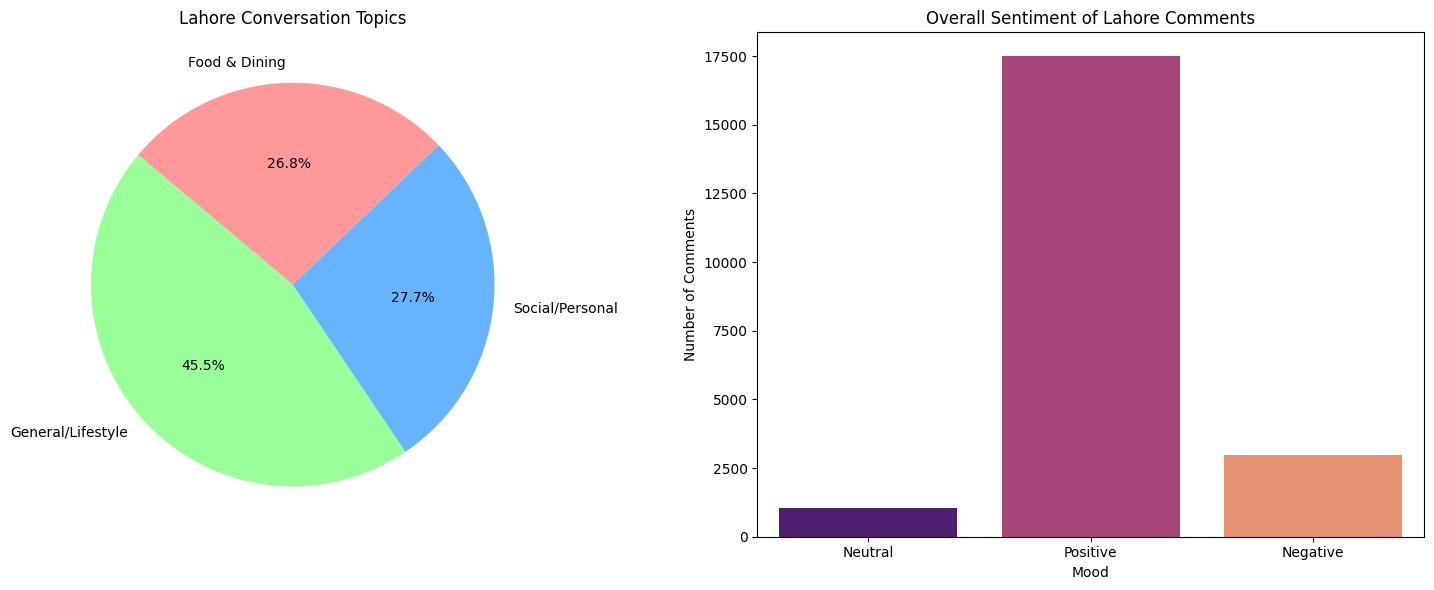

📈 Visuals successfully generated!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two charts side-by-side
plt.figure(figsize=(15, 6))

# 1. Topic Distribution (Pie Chart)
# Fixed the autopct string to correctly show percentages
plt.subplot(1, 2, 1)
final_file['topic_name'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#99ff99','#66b3ff','#ff9999'],
    startangle=140
)
plt.title('Lahore Conversation Topics')
plt.ylabel('')

# 2. Sentiment Breakdown (Bar Chart)
# Shows the city's mood across all comments
plt.subplot(1, 2, 2)
sns.countplot(x='mood', data=final_file, hue='mood', palette='magma', legend=False)
plt.title('Overall Sentiment of Lahore Comments')
plt.xlabel('Mood')
plt.ylabel('Number of Comments')

plt.tight_layout()
plt.show()

print("📈 Visuals successfully generated!")

In [11]:
# MOCK API ENGINE
def lahore_lens_api(user_comment):
    # 1. Logic to predict topic based on our LDA keywords
    food_keywords = ['food', 'best', 'good', 'restaurant', 'visit', 'eat']

    # Simple logic for this demonstration
    if any(word in user_comment.lower() for word in food_keywords):
        topic = "Food & Dining"
    else:
        topic = "General/Social"

    # 2. Get the Sentiment (Mood)
    # In the real API, this part calls Hugging Face
    analysis = TextBlob(user_comment)
    mood = "Positive" if analysis.sentiment.polarity > 0 else "Negative" if analysis.sentiment.polarity < 0 else "Neutral"

    return {"comment": user_comment, "topic": topic, "mood": mood}

# TEST THE API
test_comment = "The biryani at this place in Lahore is the best I ever had!"
print(f"🚀 API Response: {lahore_lens_api(test_comment)}")

🚀 API Response: {'comment': 'The biryani at this place in Lahore is the best I ever had!', 'topic': 'Food & Dining', 'mood': 'Positive'}
